Імпорт бібліотек та завантаження даних

In [1]:
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю для академічних графіків
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

DATA_DIR = "." 

# Завантаження даних
with open(f"{DATA_DIR}/benchmark_clean.json", "r") as f:
    bench_clean = json.load(f)

with open(f"{DATA_DIR}/benchmark_noisy.json", "r") as f:
    bench_noisy = json.load(f)

with open(f"{DATA_DIR}/inference_speed.json", "r") as f:
    inference = json.load(f)

with open(f"{DATA_DIR}/training_metadata.json", "r") as f:
    metadata = json.load(f)

with open(f"{DATA_DIR}/trajectories_ppo.json", "r") as f:
    traj_ppo = json.load(f)

with open(f"{DATA_DIR}/trajectories_neat.json", "r") as f:
    traj_neat = json.load(f)

print("Дані успішно завантажено!")

Дані успішно завантажено!


Порівняння продуктивності (Швидкість інференсу)

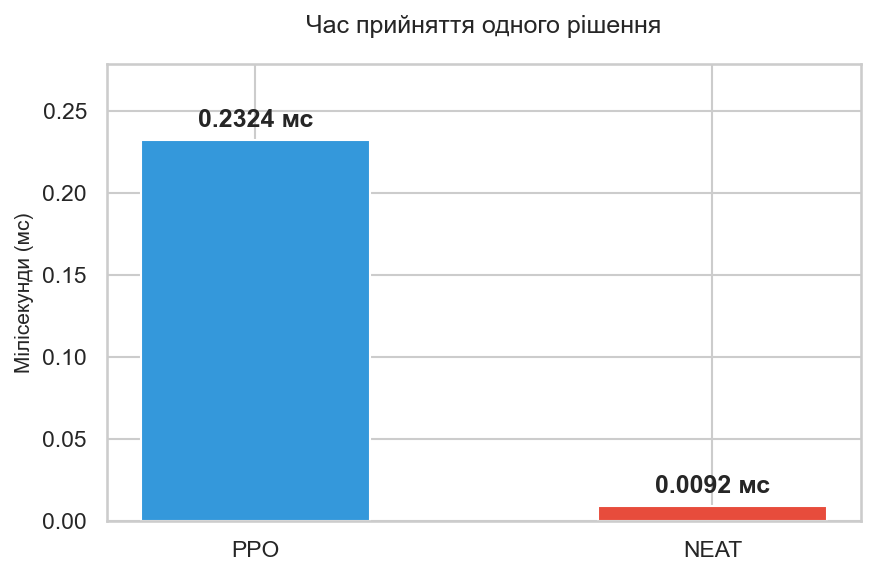

In [2]:
models = ['PPO', 'NEAT']
times_ms = [inference['ppo']['per_call_ms'], inference['neat']['per_call_ms']]
speedup = inference['speedup_neat_over_ppo']

plt.figure(figsize=(6, 4))
bars = plt.bar(models, times_ms, color=['#3498db', '#e74c3c'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.4f} мс", ha='center', va='bottom', fontweight='bold')

plt.title('Час прийняття одного рішення', fontsize=12, pad=15)
plt.ylabel('Мілісекунди (мс)', fontsize=10)
plt.ylim(0, max(times_ms) * 1.2)

plt.tight_layout()
import os
os.makedirs(f"{DATA_DIR}/plots/general", exist_ok=True)
plt.savefig(f"{DATA_DIR}/plots/general/inference_speed.png", bbox_inches='tight', dpi=300)
plt.show()


Генералізація та Прогрес (Ідеальні умови vs Шум)

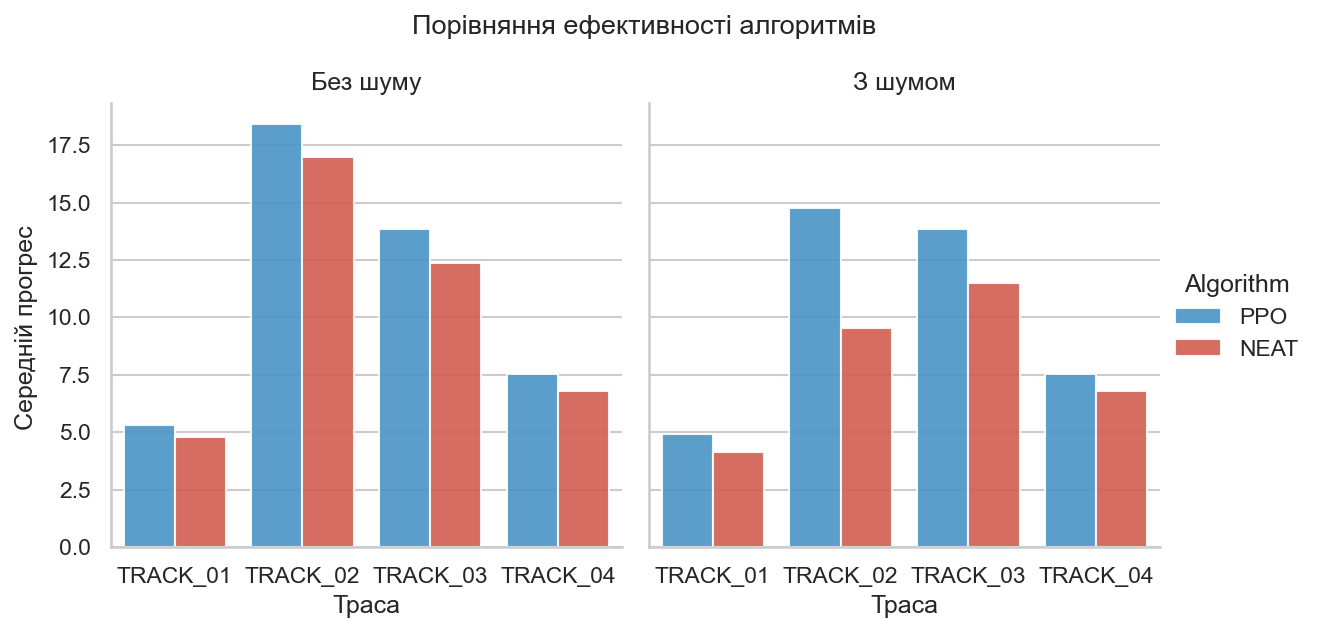

In [3]:
records = []
for track in bench_clean.keys():
    for algo in ['ppo', 'neat']:
        records.append({
            'Track': track.upper(),
            'Algorithm': algo.upper(),
            'Progress': bench_clean[track][algo]['mean_progress'],
            'Condition': 'Без шуму'
        })
        records.append({
            'Track': track.upper(),
            'Algorithm': algo.upper(),
            'Progress': bench_noisy[track][algo]['mean_progress'],
            'Condition': 'З шумом'
        })

df_bench = pd.DataFrame(records)

g = sns.catplot(
    data=df_bench, kind="bar",
    x="Track", y="Progress", hue="Algorithm", col="Condition",
    palette=['#3498db', '#e74c3c'], height=4, aspect=1.0, alpha=0.9
)

g.set_axis_labels("Траса", "Середній прогрес ")
g.set_titles("{col_name}")
g.fig.suptitle('Порівняння ефективності алгоритмів', y=1.05, fontsize=13)

import os
os.makedirs(f"{DATA_DIR}/plots/general", exist_ok=True)
plt.savefig(f"{DATA_DIR}/plots/general/benchmark_comparison.png", bbox_inches='tight', dpi=300)
plt.show()


Аналіз траєкторій (Просторова поведінка)

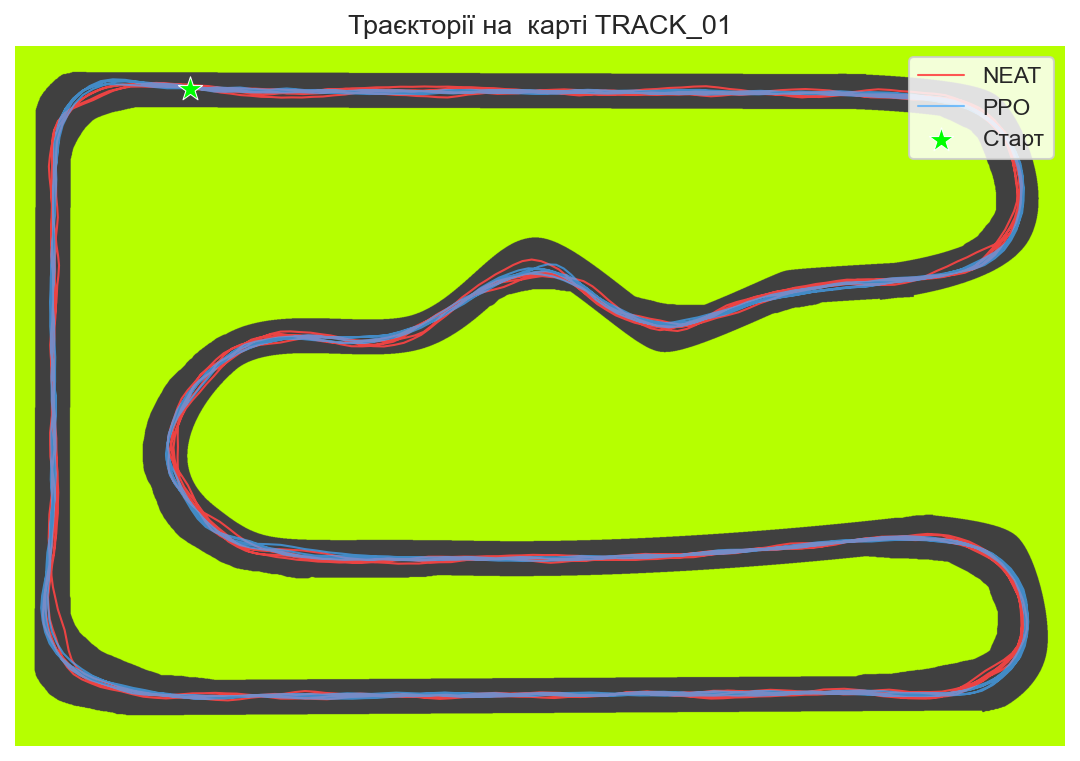

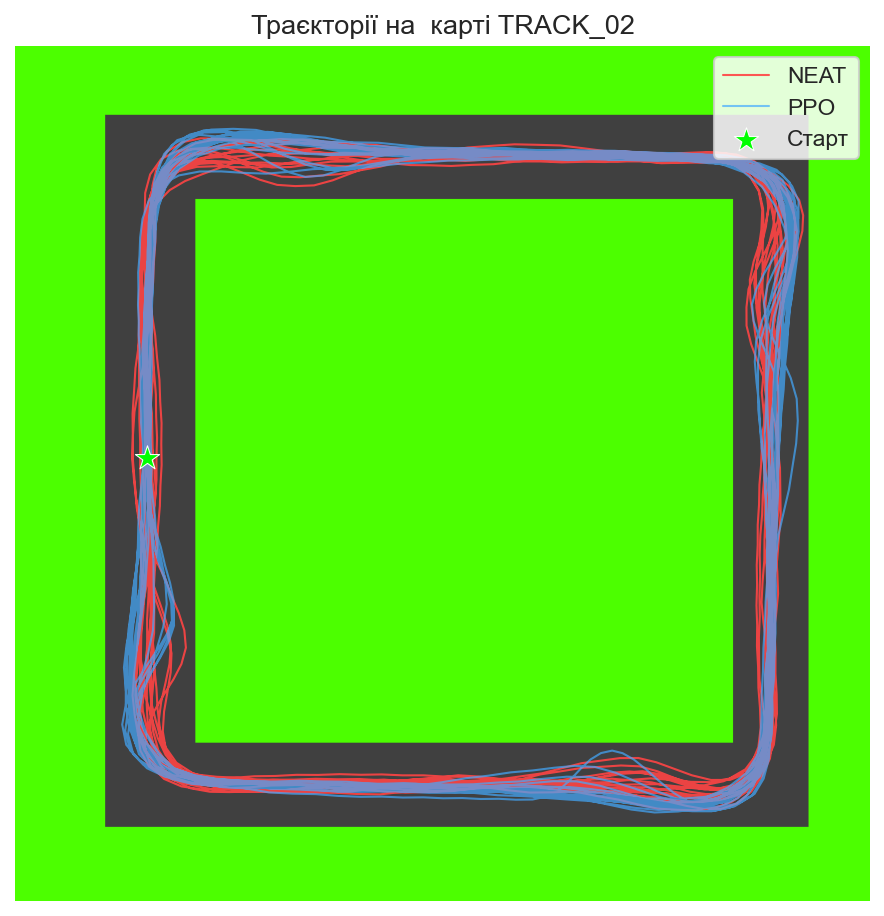

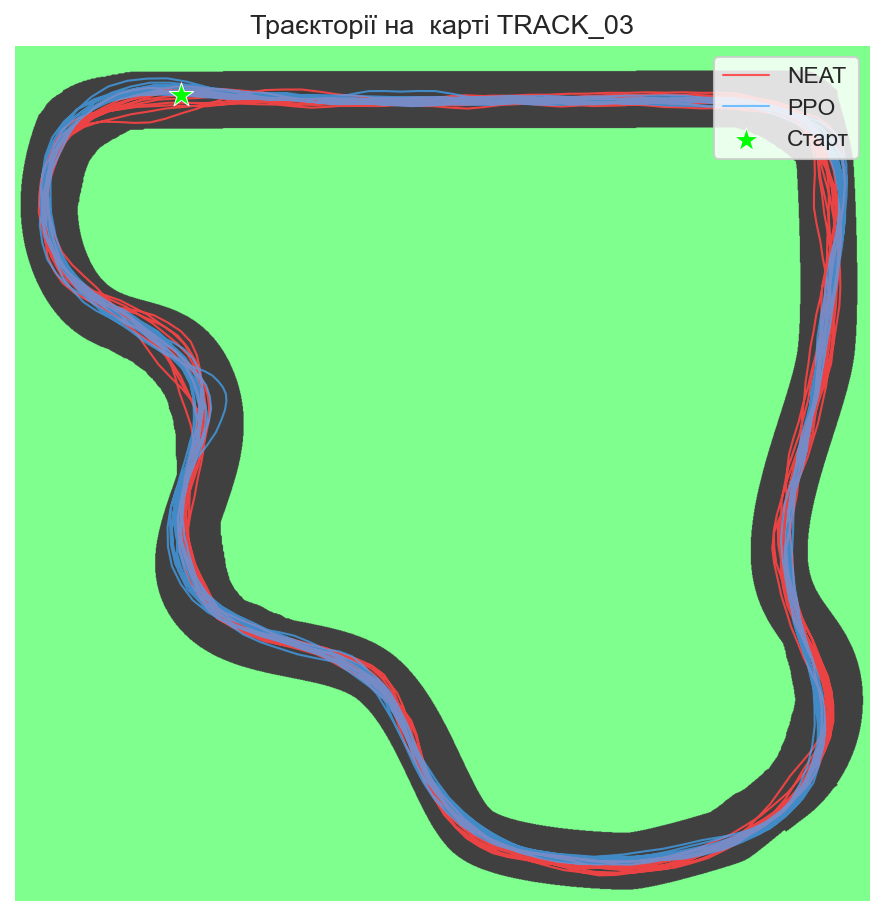

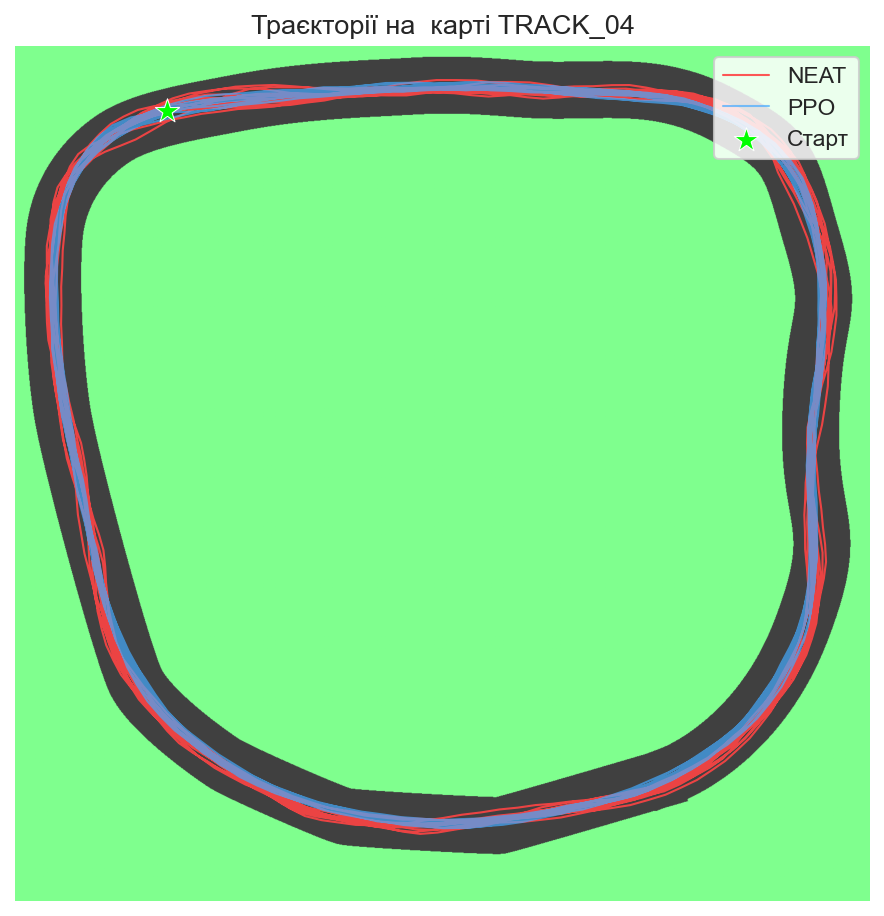

In [4]:
import matplotlib.image as mpimg
import os

tracks = ["track_01", "track_02", "track_03", "track_04"]

for track_to_plot in tracks:
    ppo_path  = pd.DataFrame(traj_ppo[track_to_plot][0]['trajectory'])
    neat_path = pd.DataFrame(traj_neat[track_to_plot][0]['trajectory'])

    track_img = mpimg.imread(f"../{track_to_plot}.png")
    img_h, img_w = track_img.shape[:2]

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.imshow(track_img, extent=[0, img_w, img_h, 0], aspect='equal')

    ax.plot(neat_path['x'], neat_path['y'],
            label='NEAT', color='#ff4444', linewidth=1, alpha=0.9)
    ax.plot(ppo_path['x'],  ppo_path['y'],
            label='PPO',  color='#44aaff', linewidth=1, alpha=0.7)

    ax.scatter(ppo_path['x'].iloc[0], ppo_path['y'].iloc[0],
               color='lime', s=150, label='Старт', zorder=6,
               marker='*', edgecolors='white', linewidths=0.5)

    ax.axis('off')

    ax.set_title(f'Траєкторії на  карті {track_to_plot.upper()}', fontsize=13)
    ax.legend(framealpha=0.85, loc='upper right')

    plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0)

    os.makedirs(f"{DATA_DIR}/plots/{track_to_plot}", exist_ok=True)
    plt.savefig(f"{DATA_DIR}/plots/{track_to_plot}/trajectory_clean_{track_to_plot}.png", bbox_inches='tight', dpi=300)
    plt.show()


Траєкторії з шумом

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import json
import os

with open(f"{DATA_DIR}/crash_map.json", "r") as f:
    crash_data = json.load(f)

tracks = ["track_01", "track_02", "track_03", "track_04"]

for track_to_plot in tracks:
    ppo_crashes = crash_data[track_to_plot]['ppo']
    neat_crashes = crash_data[track_to_plot]['neat']

    num_ppo_crashes = len(ppo_crashes)
    num_neat_crashes = len(neat_crashes)

    track_img = mpimg.imread(f"../{track_to_plot}.png")
    img_h, img_w = track_img.shape[:2]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.imshow(track_img, extent=[0, img_w, img_h, 0], aspect='equal')

    for i, crash in enumerate(neat_crashes):
        traj = pd.DataFrame(crash['trajectory'])
        label_line = 'Траєкторія NEAT (Шум)' if i == 0 else None
        label_crash = f'Аварії NEAT (Всього: {num_neat_crashes})' if i == 0 else None
        
        ax.plot(traj['x'], traj['y'], color='#ff4444', linewidth=1, alpha=0.45, label=label_line)
        ax.scatter(crash['pos']['x'], crash['pos']['y'], color='#ff4444', marker='X', s=50, 
                   edgecolors='black', linewidths=0.5, zorder=5, label=label_crash)

    for i, crash in enumerate(ppo_crashes):
        traj = pd.DataFrame(crash['trajectory'])
        label_line = 'Траєкторія PPO (Шум)' if i == 0 else None
        label_crash = f'Аварії PPO (Всього: {num_ppo_crashes})' if i == 0 else None
        
        ax.plot(traj['x'], traj['y'], color='#44aaff', linewidth=1, alpha=0.65, label=label_line)
        ax.scatter(crash['pos']['x'], crash['pos']['y'], color='#44aaff', marker='X', s=50, 
                   edgecolors='black', linewidths=0.5, zorder=6, label=label_crash)

    ax.set_title(f'Карта траєкторій та місць аварій з шумом ({track_to_plot.upper()})', fontsize=14, pad=15)
    ax.axis('off')
    ax.legend(framealpha=0.6, loc='upper right', fontsize=8)
    plt.subplots_adjust(left=0, right=1, top=0.95, bottom=0)

    os.makedirs(f"{DATA_DIR}/plots/{track_to_plot}", exist_ok=True)
    plt.savefig(f"{DATA_DIR}/plots/{track_to_plot}/crash_map_{track_to_plot}.png", bbox_inches='tight', dpi=300)
    plt.show()


Емерджентна поведінка 

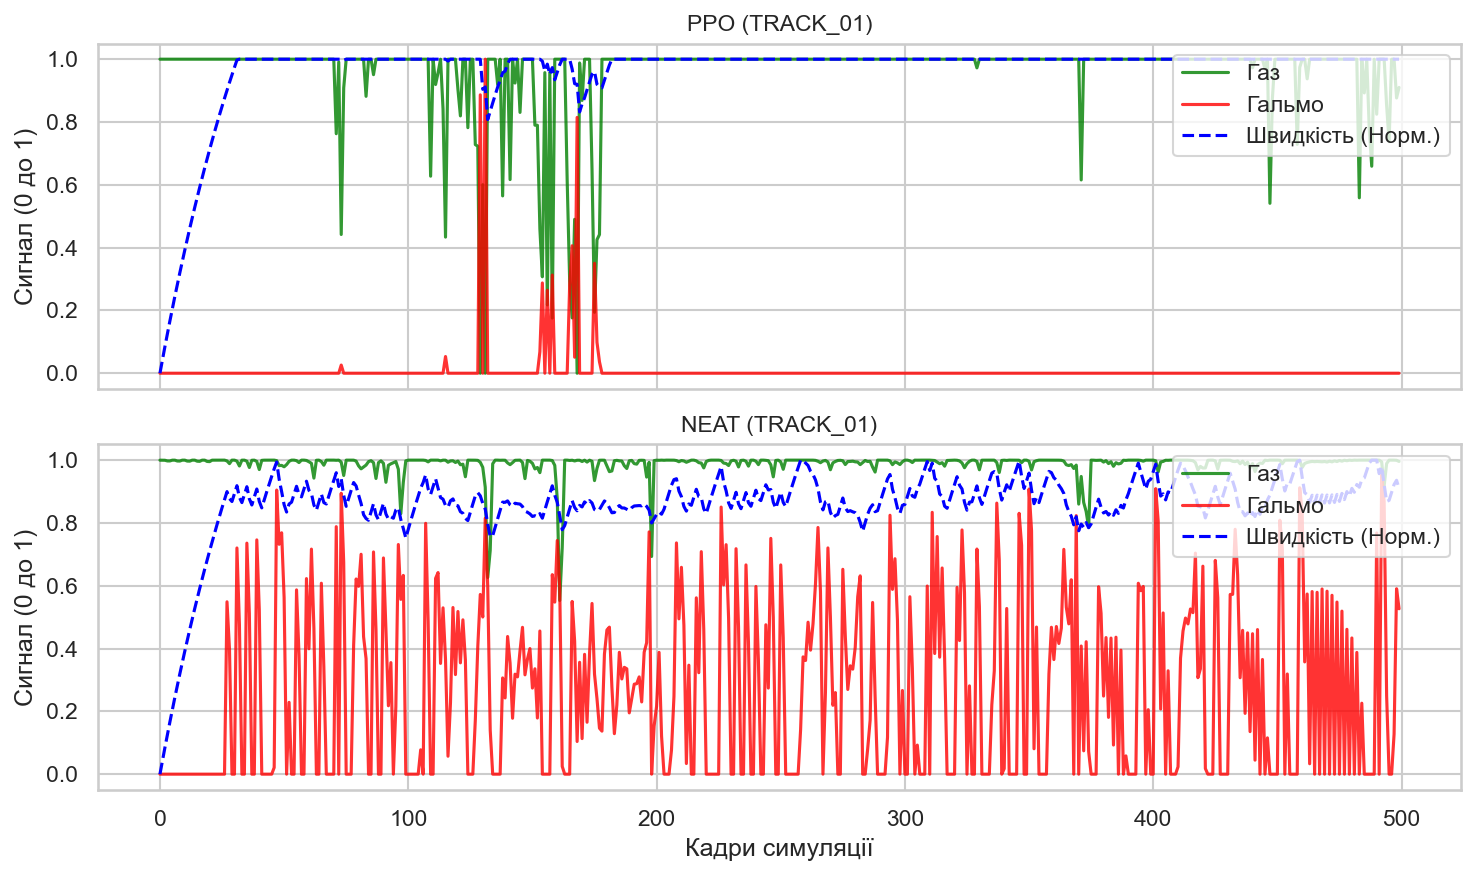

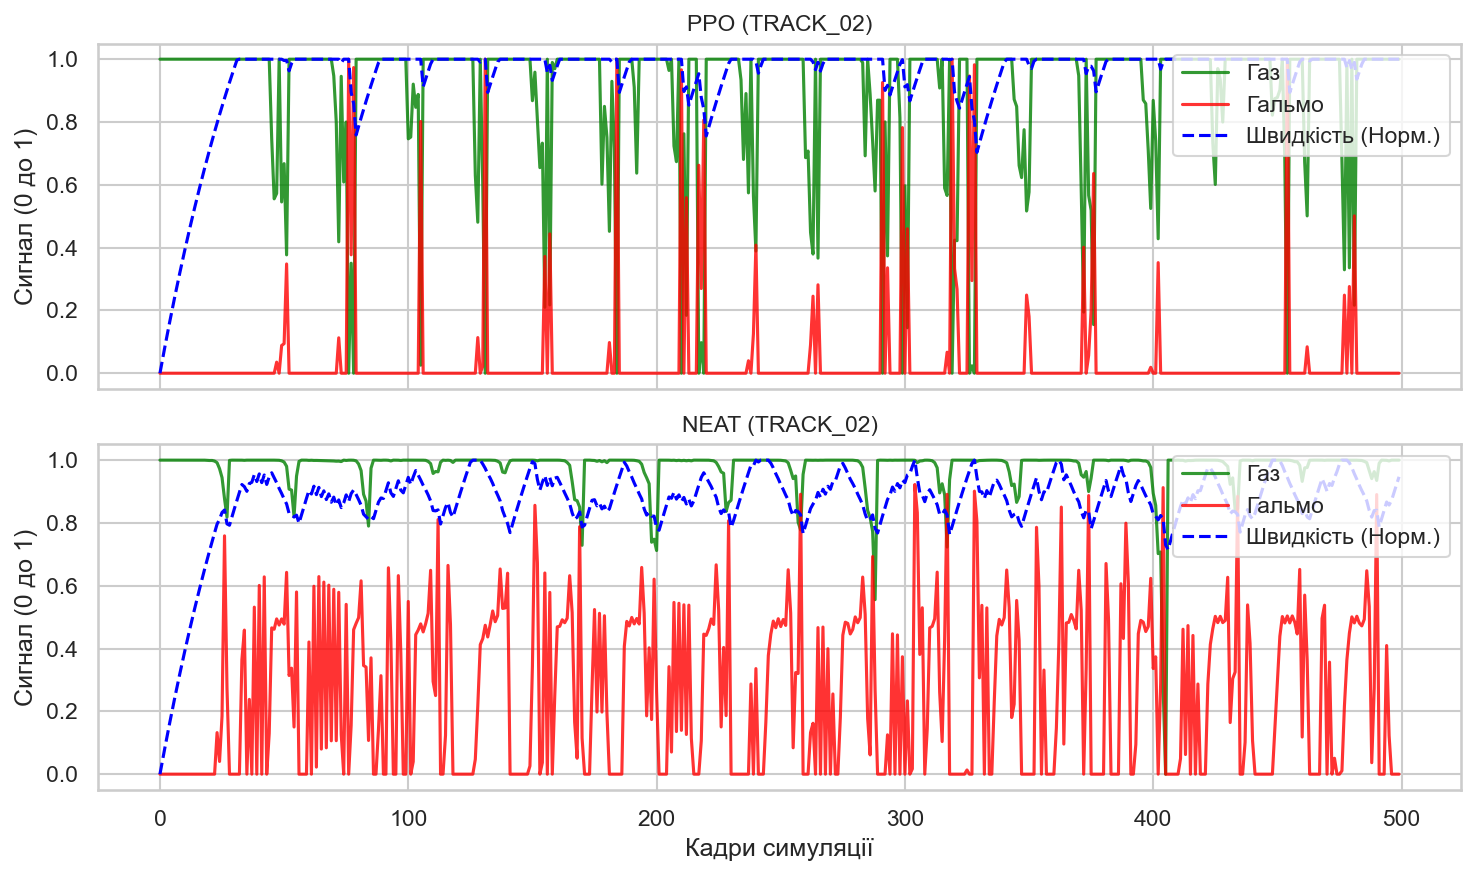

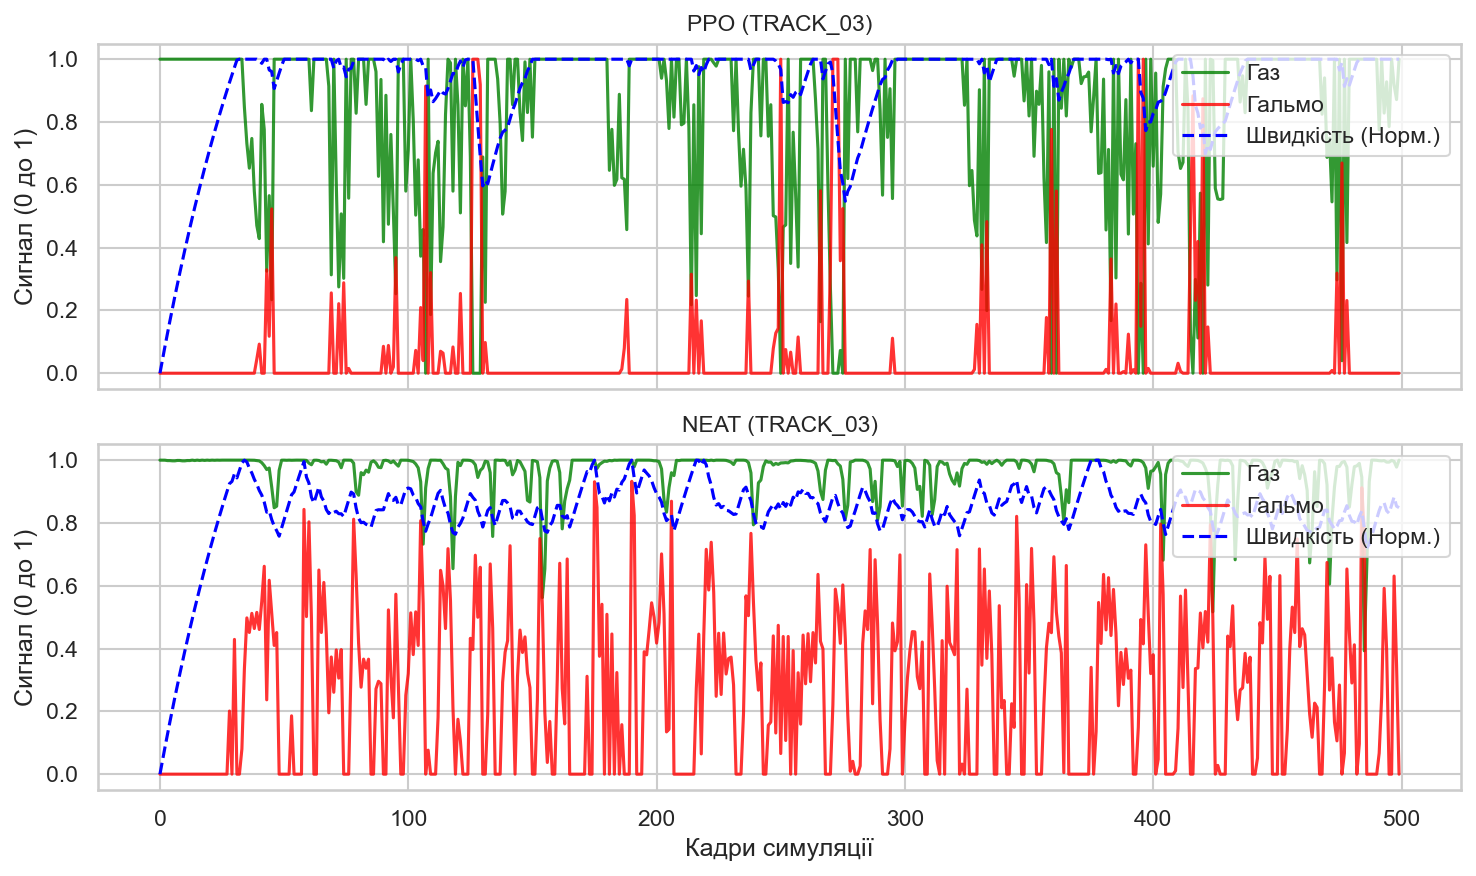

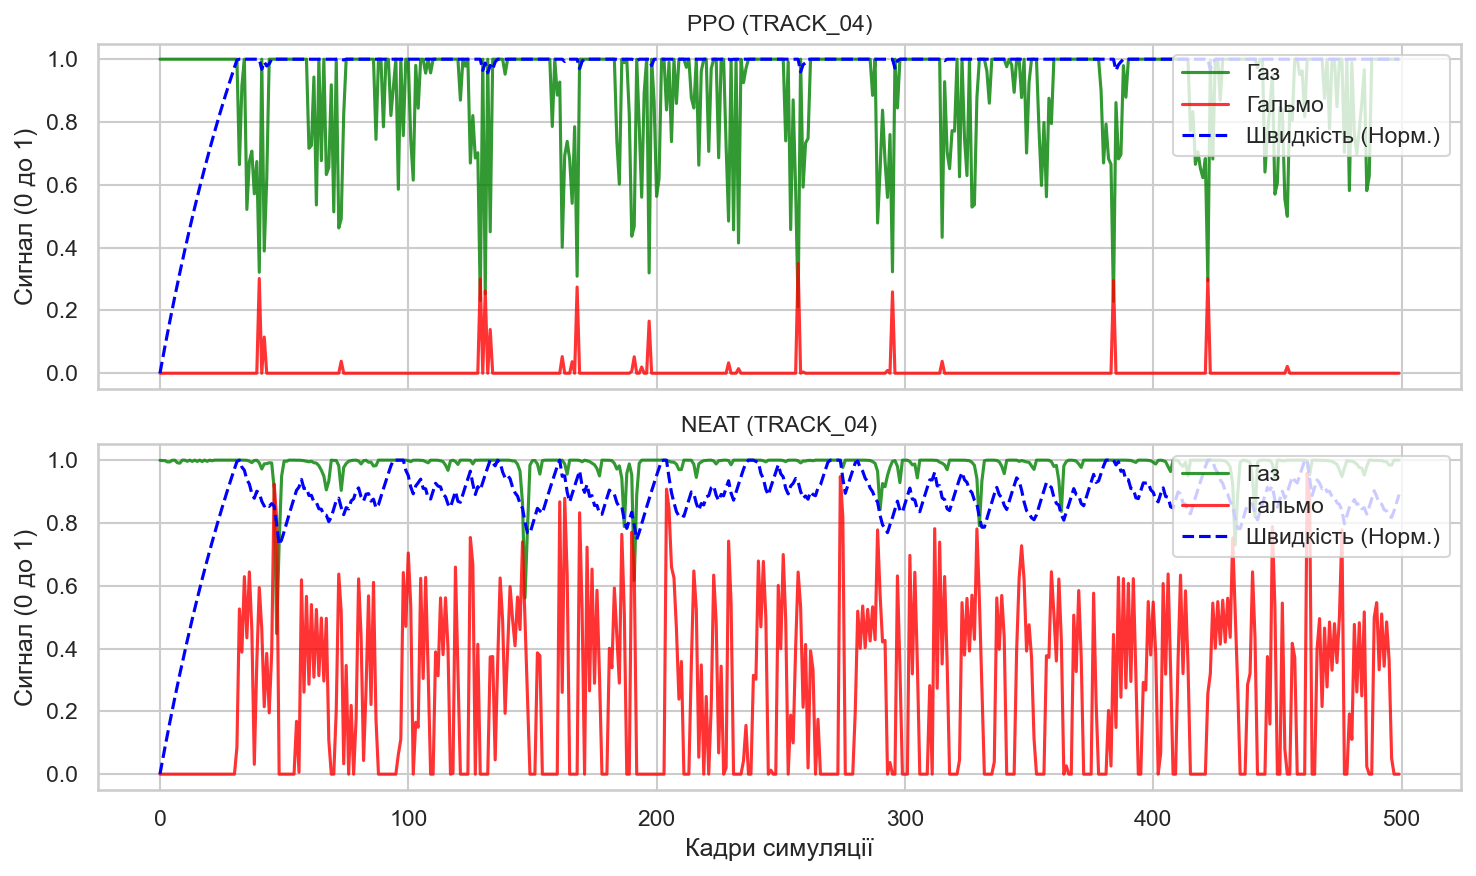

In [6]:
import os
tracks = ["track_01", "track_02", "track_03", "track_04"]
frames_limit = 500  

for track_to_plot in tracks:
    ppo_df  = pd.DataFrame(traj_ppo[track_to_plot][0]['trajectory']).head(frames_limit)
    neat_df = pd.DataFrame(traj_neat[track_to_plot][0]['trajectory']).head(frames_limit)

    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    axes[0].plot(ppo_df['frame'], ppo_df['gas'],   label='Газ',   color='green', alpha=0.8)
    axes[0].plot(ppo_df['frame'], ppo_df['brake'],  label='Гальмо', color='red',   alpha=0.8)
    axes[0].plot(ppo_df['frame'], ppo_df['speed'] / ppo_df['speed'].max(),
                 label='Швидкість (Норм.)', color='blue', linestyle='--')
    axes[0].set_title(f'PPO ({track_to_plot.upper()})', fontsize=11)
    axes[0].set_ylabel('Сигнал (0 до 1)')
    axes[0].legend(loc='upper right')

    axes[1].plot(neat_df['frame'], neat_df['gas'],   label='Газ',   color='green', alpha=0.8)
    axes[1].plot(neat_df['frame'], neat_df['brake'],  label='Гальмо', color='red',   alpha=0.8)
    axes[1].plot(neat_df['frame'], neat_df['speed'] / neat_df['speed'].max(),
                 label='Швидкість (Норм.)', color='blue', linestyle='--')
    axes[1].set_title(f'NEAT ({track_to_plot.upper()})', fontsize=11)
    axes[1].set_ylabel('Сигнал (0 до 1)')
    axes[1].set_xlabel('Кадри симуляції')
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    os.makedirs(f"{DATA_DIR}/plots/{track_to_plot}", exist_ok=True)
    plt.savefig(f"{DATA_DIR}/plots/{track_to_plot}/emergent_behavior_{track_to_plot}.png", bbox_inches='tight', dpi=300)
    plt.show()
